## Compare pepnets and epicore
This notebook employs immunopeptidome data from a benign [reference dataset](https://doi.org/10.1186/s13059-025-03763-8).

In [ ]:
# import
import random
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import ast
import numpy as np
from matplotlib_venn import venn2
import subprocess
import time
import sys
sys.path.append('../../pepnets')
sys.path.append('../functions')
from pepnets.PeptideNetwork import PeptideNetwork
from pepnets.FeatureMatrix import FeatureMatrix
from analyze_pepnets import update_landscape, id_consensus
from analyze_overlap import all_overlap
from peptide_annotator import get_peptide_lengths, proteome_to_dict, create_fasta_dict, annotate_peptides, add_positions

/mnt/volume/jana/thesis/epicore_kernel/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Prepare data

In [ ]:
# load benign data
benign_df = pd.read_csv('/mnt/volume/jana/thesis/data/newbenign/benign_HLA_Ligand_Atlas_Lumos_timsTOF.tsv',sep='\t', usecols=['mhc_class', 'peptide_sequence'])
benign_df = benign_df.drop_duplicates('peptide_sequence')
benign_df = benign_df[benign_df['mhc_class']=='II']
benign_df = benign_df.rename(columns={'peptide_sequence':'sequence'})

# annotate data
lengths = get_peptide_lengths(benign_df)
proteome_dict = proteome_to_dict('/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta')
fasta_dict = create_fasta_dict(proteome_dict, lengths)
benign_df = annotate_peptides(fasta_dict, benign_df)
benign_df['sample'] = 'sample'
benign_df['condition'] = 'condition'
benign_df.to_csv('benign.csv')

In [160]:
# prepare input 
benign_df = pd.read_csv('benign.csv', index_col=[0])
benign_df = benign_df[['sequence','accessions']]
benign_df = benign_df.rename(columns={'accessions':'Protein','sequence':'Peptide'})
benign_df['Protein'] = benign_df['Protein'].apply(lambda proteins: proteins.split(';'))
benign_df = benign_df.explode('Protein')
benign_df = benign_df.drop_duplicates()
proteome_dict = proteome_to_dict('/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta')
benign_df['Sample'] = '1'
benign_df['id'] = [i for i in range(len(benign_df))]

#### Run epicore and pepnets

In [55]:

start_time =  time.time()
# run pepnets
pnet = PeptideNetwork(
    datamatrix=benign_df,
    protein_database=proteome_dict,
)
pnet.datamatrix
_ = pnet.create_network(distance_cutoff=4)
resolution = 0.08
clusters = pnet.get_clusters(resolution=resolution, random_seed=42)
clusters.merge_nearby_clusters(wiggle_room=2)
clusters.reindex()

end_time = time.time()

Reading peptides...
Merged 400 clusters



In [ ]:
# get clusters
design = pd.DataFrame({'sample':['1'], 'group':['one'], 'day':[0], 'id':[1]})
fm = FeatureMatrix(benign_df, design, clusters)
dm = fm.datamatrix
dm
dm.to_csv('pepnets_cluster.csv')

,Peptide,Protein,Sample,id,Cluster,Cluster_start,Cluster_end
0,KEYFAIDNSGRII,sp|P33151|CADH5_HUMAN,1,0,sp|P33151|CADH5_HUMAN_12,190.0,210.0
1,APITGYRIVYSPSV,sp|P02751|FINC_HUMAN,1,1,sp|P02751|FINC_HUMAN_31,835.0,852.0
2,QFMWIIRKRIQLPS,sp|P60520|GBRL2_HUMAN,1,2,sp|P60520|GBRL2_HUMAN_4,56.0,69.0
3,HFGKEFTPPVQAAYQKVVAGVANALAHKYH,sp|P68871|HBB_HUMAN,1,3,sp|P68871|HBB_HUMAN_5,115.0,147.0
4,GLEKKDVLPTVDPTKLTWGPYLWF,sp|Q8N128|F177A_HUMAN,1,4,sp|Q8N128|F177A_HUMAN_2,77.0,101.0
...,...,...,...,...,...,...,...
4304455,AESTGGKRLLIPVVPGVDSLNSAMAASILL,sp|Q9HC36|MRM3_HUMAN,1,463887,sp|Q9HC36|MRM3_HUMAN_1,369.0,399.0
4304502,VAKPSVSVEFVTNM,sp|P04114|APOB_HUMAN,1,463888,sp|P04114|APOB_HUMAN_90,873.0,887.0
4304520,IQYNREADGILKPLPK,sp|P49588|SYAC_HUMAN,1,463889,sp|P49588|SYAC_HUMAN_6,217.0,235.0
4304524,HLEINPDHSIIET,sp|P07900|HS90A_HUMAN,1,463890,sp|P07900|HS90A_HUMAN_81,636.0,655.0


In [167]:
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta', '--out_dir', 'benignd', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'benign.csv','--sample_column', 'sample', '--condition_column', 'condition', '--included','--QC'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta', '--out_dir', 'benignd', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'benign.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--included', '--QC'], returncode=0)

#### Compare epicore and pepnets

In [7]:
def reorder_peptides(row: pd.Series) -> pd.Series:
    """Reorder the peptides mapped to a protein by their position.
    
    Args:
        row: A row of a pandas dataframe containing per row one protein, 
            peptides mapped to the protein, start and end position of the peptide in the protein and the intensity of the peptide.
        intensity_column: The header of the column containing the intensities
            of the peptides.
    Returns:
        A reordered version of the input row, where the start positions are sorted in ascending order, the indices of the other columns are reordered in the same pattern. 
    """
    lists = list(zip(row['start'], row['end'], row['Peptide']))
    lists = sorted(lists, key=lambda x: int(x[1]), reverse=True)
    sorted_lists = sorted(lists, key=lambda x: int(x[0]))
    starts, ends, sequences = zip(*sorted_lists)
    return list(starts), list(ends), list(sequences)



In [139]:
dm = pd.read_csv('pepnets_cluster.csv', index_col=[0])
epicore_groups = pd.read_csv('benign/epitopes.csv', index_col=[0])

In [ ]:
# convert pepnets to epicore output
# add start and end positions to the pepnets result
pepnets_df = add_positions(proteome_dict, dm,'Protein','Peptide')
pepnets_df['start'] = pepnets_df['start'].apply(lambda cell: str(cell).split(';'))
pepnets_df['end'] = pepnets_df['end'].apply(lambda cell: str(cell).split(';'))
pepnets_df['start'] = pepnets_df.apply(lambda cell: cell['start'][np.argmin([np.abs(int(s)-cell['Cluster_start']) for s in cell['start']])], axis=1)
pepnets_df['end'] = pepnets_df.apply(lambda cell: cell['end'][np.argmin([np.abs(int(s)-cell['Cluster_end']) for s in cell['end']])], axis=1)
pepnets_df['Cluster_start'] = pepnets_df['Cluster_start'].astype(int)
pepnets_df['start'] = pepnets_df['start'].astype(int)
pepnets_df['Cluster_end'] = pepnets_df['Cluster_end'].astype(int)
pepnets_df['end'] = pepnets_df['end'].astype(int)

pepnets_df = pepnets_df.groupby('Cluster').agg({'Peptide':list,'Protein':'first','Cluster_start':'first','Cluster_end':'first','start':list,'end':list}).reset_index()
pepnets_df[['start', 'end', 'Peptide']] = pepnets_df.apply(lambda row: pd.Series(reorder_peptides(row)), axis=1)

# identify landscapes
pepnets_df['landscape'] = pepnets_df.apply(lambda row: np.zeros(max(row['end'])-min(row['start'])+1), axis=1)

# get landscape sequence
pepnets_df['landscape_seq'] = pepnets_df.apply(lambda row: proteome_dict[row['Protein']][min(row['start']):max(row['end'])+1],axis=1)

# update landscape
pepnets_df['landscape'] = pepnets_df.apply(lambda row: update_landscape(row['landscape'],row['start'], row['end']), axis=1)

# compute consensus sequences and entire sequence for each peptide group
pepnets_df[['consensus_sequence','consensus_start','consensus_end']] = pepnets_df.apply(lambda row: id_consensus(row['landscape'], 9, row['landscape_seq']), axis=1, result_type='expand')
pepnets_df['entire_sequence'] = pepnets_df.apply(lambda row: proteome_dict[f"{row['Cluster'].split('_')[0]}_{row['Cluster'].split('_')[1]}"][min(row['start']):max(row['end'])+1],axis=1)
pepnets_df['consensus_start'] = pepnets_df.apply(lambda row: row['consensus_start']+min(row['start']), axis=1)
pepnets_df['consensus_end'] = pepnets_df.apply(lambda row: row['consensus_end']+min(row['start']), axis=1)

pepnets_df = pepnets_df.sort_values('Cluster_start')

# grouby accession
pepnets_df = pepnets_df.groupby('Protein').agg({'Peptide':list,'Cluster_start':list,'Cluster_end':list,'start':list,'end':list,'landscape':list, 'consensus_sequence':list, 'entire_sequence':list, 'consensus_start':list, 'consensus_end':list}).reset_index()

In [ ]:
# read in epicore results
epicore_df = pd.read_csv('benign/epicore_result.csv', index_col=[0])
epicore_df['grouped_peptides_start'] = epicore_df['grouped_peptides_start'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['grouped_peptides_end'] = epicore_df['grouped_peptides_end'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['grouped_peptides_sequence'] = epicore_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['core_epitopes_start'] = epicore_df['core_epitopes_start'].apply(lambda cell: ast.literal_eval(cell))
epicore_df['core_epitopes_end'] = epicore_df['core_epitopes_end'].apply(lambda cell: ast.literal_eval(cell))

In [52]:
# determine intern and extern ratio
pepnets_df['grouped_peptides_start'] = pepnets_df['start']
pepnets_df['grouped_peptides_end'] = pepnets_df['end']
pepnets_df['grouped_peptides_sequence'] = pepnets_df['Peptide']
pepnets_df['core_epitopes_start'] = pepnets_df['consensus_start']
pepnets_df['core_epitopes_end'] = pepnets_df['consensus_end']
pepnets_overlap = pd.concat([*pepnets_df.apply(lambda row: all_overlap(row), axis=1)])
pepnets_overlap["intern_ratio"] = pepnets_overlap["intern_max"] / pepnets_overlap["len_pep"]
pepnets_overlap["extern_ratio"] = pepnets_overlap.apply(
    lambda row: min(1, max(row["previous"], row["next"]) / row["len_pep"]), axis=1
)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

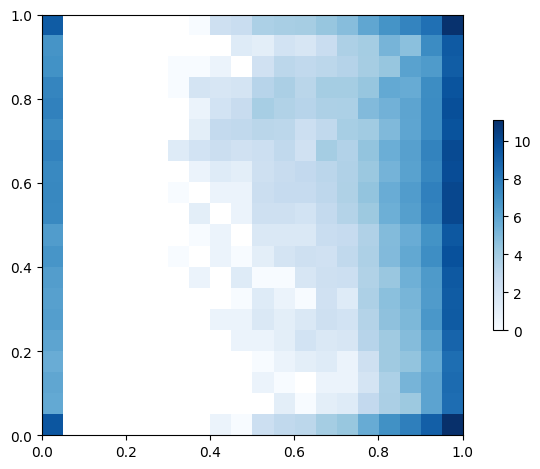

In [98]:
fig, axis=plt.subplots(1,1)
matrixpepnets, xedges, yedges = np.histogram2d(pepnets_overlap['intern_ratio'],pepnets_overlap['extern_ratio'], bins=20)
im1 = axis.imshow(np.log(np.flip(matrixpepnets.T,0)), extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')
plt.colorbar(im1, ax=axis,shrink=0.5)
fig.tight_layout()

In [ ]:
# determine overlaps for epicore results
epicore_overlap = pd.concat([*epicore_df.apply(lambda row: all_overlap(row), axis=1)])
epicore_overlap["intern_ratio"] = epicore_overlap["intern_max"] / epicore_overlap["len_pep"]
epicore_overlap["extern_ratio"] = epicore_overlap.apply(
    lambda row: min(1, max(row["previous"], row["next"]) / row["len_pep"]), axis=1
)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

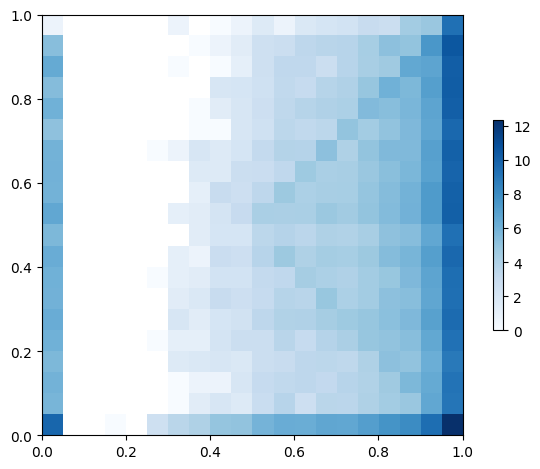

In [97]:
fig, axis=plt.subplots(1,1)
matrixepicore, xedges, yedges = np.histogram2d(epicore_overlap['intern_ratio'],epicore_overlap['extern_ratio'], bins=20)
im1 = axis.imshow(np.log(np.flip(matrixepicore.T,0)), extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')
plt.colorbar(im1, ax=axis,shrink=0.5)
fig.tight_layout()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

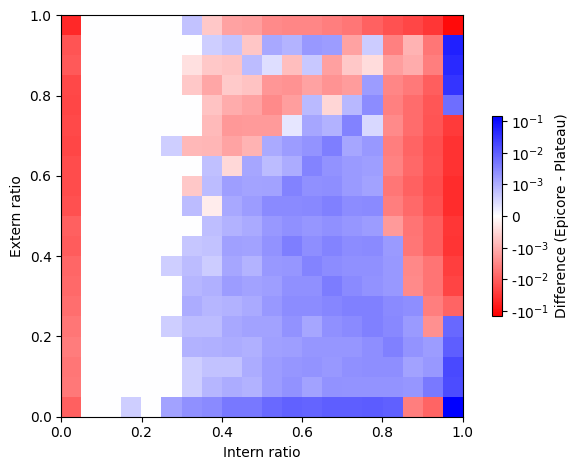

In [136]:
fig, axis = plt.subplots(ncols=1)
matrixpepnets_n = matrixpepnets/np.sum(matrixpepnets)
matrixepicore_n = matrixepicore/np.sum(matrixepicore)
matrix = matrixepicore_n - matrixpepnets_n 

matrix[matrix<0] = -np.log10(np.abs(matrix[matrix<0]*10000000))
matrix[matrix==0] = 0
matrix[matrix>0] = np.log10(matrix[matrix>0]*10000000)

im1 = axis.imshow(np.flip(matrix.T,0), extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='bwr_r', norm=matplotlib.colors.CenteredNorm()) # more epicore
cbar = plt.colorbar(im1, ax=axis,shrink=0.5, label='Difference (Epicore - Plateau)')

cbar.set_ticks(ticks=[-6,-4,-2,0,2,4,6], labels=[r'-$10^{-1}$',r'-$10^{-2}$',r'-$10^{-3}$',0,r'$10^{-3}$',r'$10^{-2}$',r'$10^{-1}$'])
plt.xlabel('Intern ratio')
plt.ylabel('Extern ratio')
fig.tight_layout()
plt.savefig('figures/pepnets_epicore.svg')

Identify number of clusters

In [142]:
epicore_df = pd.read_csv('benign/epitopes.csv', index_col=[0])
print(f"Pepnets calculated {len(dm['Cluster'].drop_duplicates())}")
print(f"Epicore calculated {len(epicore_df.drop_duplicates(['whole_epitopes', 'consensus_epitopes']))}")

Pepnets calculated 86800
Epicore calculated 63686


In [ ]:
pepnets_id = dm.groupby('Cluster').agg({'Peptide':list, 'start':min, 'end':min, 'Cluster_start':'first', 'Cluster_end':'first'})
print(f"Pepnets groups summarize {pepnets_id['Peptide'].str.split(';').str.len().mean()} peptides on average ({pepnets_id['Peptide'].str.split(';').str.len().min()}-{pepnets_id['Peptide'].str.split(';').str.len().max()}).")
print(f"Epicore groups summarize {epicore_df['grouped_peptides_sequence'].str.split(';').str.len().mean()} peptides on average ({epicore_df['grouped_peptides_sequence'].str.split(';').str.len().min()}-{epicore_df['grouped_peptides_sequence'].str.split(';').str.len().max()}).")

Pepnets groups summarize 5.280990783410139 peptides on average (1-580).
Epicore groups summarize 7.994292837511076 peptides on average (1-241).


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

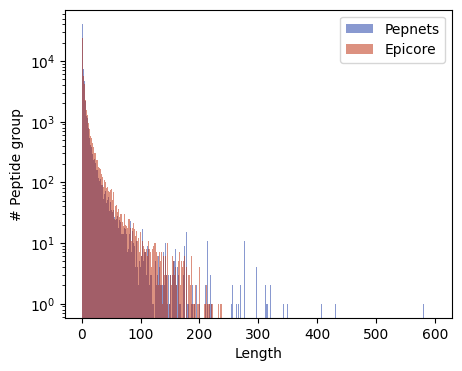

In [51]:
fig, ax = plt.subplots(1,figsize=(5,4))
plt.hist(pepnets_id['Peptide'].str.split(';').str.len(),bins=[i for i in range(1,600)], color="#1435a2f3", alpha=0.5, label='Pepnets')
plt.hist(epicore_df['grouped_peptides_sequence'].str.split(';').str.len(),bins=[i for i in range(1,600)], color="#bb2402cf", alpha=0.5, label='Epicore')
plt.legend()
plt.yscale('log')
plt.xlabel('Length')
plt.ylabel('# Peptide group')
plt.savefig('figures/length_distribution.svg')
plt.show()

In [153]:
pepnets_df['length'] = pepnets_df.apply(lambda cell: [max(ends)-min(starts) for starts, ends in zip(cell['start'], cell['end'])], axis=1)

In [157]:
print(f"Pepnets groups have an average length of {pepnets_df['length'].explode().mean()} ({pepnets_df['length'].explode().min()}-{pepnets_df['length'].explode().max()}).")
print(f"Epicore groups have an average length of {epicore_df['whole_epitopes'].str.len().mean()} ({epicore_df['whole_epitopes'].str.len().min()}-{epicore_df['whole_epitopes'].str.len().max()}).")

Pepnets groups have an average length of 16.504619815668203 (7-67).
Epicore groups have an average length of 18.811918958292658 (8-144).


In [18]:
print(f"{len(set(pd.read_csv('benign.csv')['sequence']) - set(dm['Peptide']))} peptides are missing in the pepnets output.")

4748 peptides are missing in the pepnets output.


In [19]:
set(pd.read_csv('benign.csv')['sequence']) - set(dm['Peptide'])

{'TPVLVVLHGIGNTF',
 'FRNWSTTDIHKHLPFIYNL',
 'FTQAEMCLPCCS',
 'TDLGNTDDFTTETL',
 'RADFVLAANSYDLAI',
 'KLLRKLDRLEKKKKKKDRKKKK',
 'VTAYRLSTGLMITSV',
 'ARDARSGRPMASGY',
 'DGQKLVHSLFESIMS',
 'GSYRAPQTAPSAQQQRPYGYEQGQYGNYQQ',
 'KVPLQEGPKSFDGNTLLNRGHAIKIK',
 'FLTEPKEVERF',
 'VPETNYLFMGDFVDRG',
 'EDIRIRAILSTYRKR',
 'FGTILPLDL',
 'VHKGIWLFGDFLCR',
 'ADGIVRIYEAPDVMNL',
 'EKKGYVMASDLRSK',
 'SLHPPDAEEDEDDGEF',
 'GMATSHSWEMPSSDTNANTSASGSAS',
 'KLKDVPLLPSLDYEKLK',
 'ESENKIPATQKS',
 'LLLPNERSF',
 'RKWYPLRPKKINLDT',
 'DTEELKSCGIQDIFVFCTRGELSKYRVP',
 'KQFHLERKRQRKPR',
 'IDQQIKTRPRKIKKDGKEGAEEIDRH',
 'SPEPYHPTLGIYARCIRNPG',
 'AELVAVITV',
 'EPRFPELAALADPHAQLL',
 'ALAAKAGLLGQPR',
 'SLELHTMCN',
 'GRLSYLPATVEPASPTP',
 'LGLLLVLPAA',
 'KLDSFLPAHLCKRGQGLFAALRGRGAR',
 'AANVATLGLL',
 'EQLQLRIAF',
 'DPLLSFHLDLGPSML',
 'RKETLIITPPSCKSH',
 'IVLLGFRSL',
 'DPGEHSFWKLIALPKVG',
 'TITGLQPE',
 'ARLYPVLLVKQDGSTIHIR',
 'LQTETSVI',
 'LSVLGLGDLADL',
 'ENPTVFKYPDFAAGWA',
 'EMEDEDTIDVFQQQTGG',
 'LTCFICLDYFSSP',
 'EIEIATVM',
 '

In [157]:
epicore_df[(epicore_df['grouped_peptides_sequence'].isin(d))&(epicore_df['landscape'].apply(lambda cell: max(ast.literal_eval(cell)))>1)]

,whole_epitopes,consensus_epitopes,landscape,grouped_peptides_sequence,grouped_peptides_sample,grouped_peptides_condition,grouped_peptides_start,grouped_peptides_end,core_epitopes_start,core_epitopes_end,accession
